# Flagged or Fraud? Starter notebook

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from sklearn.model_selection import train_test_split

## Load data

In [ ]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [ ]:
train.head()

,transaction_id,terminal_id,amount_inr,customer_avg_spend_90d,card_age_days,transaction_hour,merchant_category,channel,card_type,city_tier,...,device_trust_score,is_international,failed_pin_attempts_24h,txn_count_last_1h,merchant_risk_score,days_since_last_chargeback,batch_number,acquirer_code,pos_software_version,is_fraud
0,TXN22765937,T11563,8070.00,2288.70,629,19,fuel,contactless,debit,tier_2,...,NaN,0,1,2,0.200,80,58,1102,4.5,0
1,TXN17516354,T12367,1125.82,1317.14,497,15,home_improvement,contactless,debit,tier_1,...,NaN,0,1,1,0.289,-1,67,1116,4.0,0
2,TXN44615150,T11208,600.00,564.06,4000,17,cash_withdrawal,atm,debit,tier_1,...,NaN,0,0,2,0.298,-1,319,1101,4.5,0
3,TXN72477147,T10210,1277.61,789.36,722,19,pharmacy,in_store,credit,tier_2,...,NaN,0,0,1,0.060,54,239,1123,3.4,0
4,TXN40714366,T10676,154.88,812.89,439,13,pharmacy,contactless,credit,tier_1,...,NaN,0,0,2,0.379,-1,308,1117,3.4,0


In [ ]:
train.describe()

,amount_inr,customer_avg_spend_90d,card_age_days,transaction_hour,distance_from_home_km,device_trust_score,is_international,failed_pin_attempts_24h,txn_count_last_1h,merchant_risk_score,days_since_last_chargeback,batch_number,acquirer_code,pos_software_version,is_fraud
count,2.000000e+04,1.579800e+04,20000.000000,20000.000000,17540.000000,5678.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000
mean,1.711725e+04,8.221352e+03,573.751500,14.333000,131.279173,0.716702,0.04790,0.069700,1.666950,0.283517,72.12120,248.527250,1112.526350,3.840675,0.503150
std,1.677360e+05,2.690338e+04,747.537864,5.299332,526.223665,0.162753,0.21356,0.271008,1.059992,0.157931,212.65284,143.415773,6.927872,0.516174,0.500003
min,1.000000e+00,4.990000e+00,3.000000,0.000000,0.100000,0.075000,0.00000,0.000000,1.000000,0.001000,-1.00000,1.000000,1101.000000,3.100000,0.000000
25%,6.586750e+02,7.590900e+02,134.000000,11.000000,2.600000,0.616000,0.00000,0.000000,1.000000,0.161000,-1.00000,125.000000,1107.000000,3.400000,0.000000
50%,2.219000e+03,2.246155e+03,304.000000,15.000000,6.200000,0.743000,0.00000,0.000000,1.000000,0.264000,-1.00000,247.000000,1113.000000,4.000000,1.000000
75%,7.648250e+03,6.593452e+03,677.000000,19.000000,20.200000,0.841000,0.00000,0.000000,2.000000,0.385250,41.00000,372.000000,1119.000000,4.200000,1.000000
max,1.250295e+07,1.570234e+06,4000.000000,23.000000,8168.100000,0.997000,1.00000,3.000000,11.000000,0.901000,2000.00000,499.000000,1124.000000,4.500000,1.000000


In [ ]:
train.isna().sum()

,0
transaction_id,0
terminal_id,0
amount_inr,0
customer_avg_spend_90d,4202
card_age_days,0
transaction_hour,0
merchant_category,0
channel,0
card_type,0
city_tier,0


## Preprocessing

In [ ]:
for df in [train, test]:
    pass

In [ ]:

from sklearn.preprocessing import StandardScaler

## Features

In [ ]:
# FEATURES = [
#     "transaction_hour",
#     "is_international",
#     "failed_pin_attempts_24h",
#     "txn_count_last_1h",
#     "merchant_risk_score",
#     "device_trust_score",
# ]
FEATURES = train.select_dtypes("number").columns.drop("is_fraud").tolist()

X = train[FEATURES].fillna(0)
X_test = test[FEATURES].fillna(0)
y = train["is_fraud"]

## Train / validation split

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

## Model

In [ ]:
keras.utils.set_random_seed(0)

model = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(4, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid"),
])
model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01), loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 4)              │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)

## Training

In [ ]:
history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                    epochs=10, batch_size=32, verbose=2)

Epoch 1/10
500/500 - 4s - 7ms/step - accuracy: 0.4929 - loss: 0.7343 - val_accuracy: 0.4972 - val_loss: 0.6925
Epoch 2/10
500/500 - 3s - 7ms/step - accuracy: 0.5297 - loss: 0.6875 - val_accuracy: 0.5795 - val_loss: 0.6774
Epoch 3/10
500/500 - 1s - 2ms/step - accuracy: 0.5834 - loss: 0.6770 - val_accuracy: 0.5997 - val_loss: 0.6695
Epoch 4/10
500/500 - 2s - 3ms/step - accuracy: 0.5934 - loss: 0.6704 - val_accuracy: 0.6025 - val_loss: 0.6639
Epoch 5/10
500/500 - 2s - 3ms/step - accuracy: 0.6014 - loss: 0.6655 - val_accuracy: 0.6097 - val_loss: 0.6596
Epoch 6/10
500/500 - 1s - 3ms/step - accuracy: 0.6072 - loss: 0.6617 - val_accuracy: 0.6150 - val_loss: 0.6561
Epoch 7/10
500/500 - 1s - 2ms/step - accuracy: 0.6129 - loss: 0.6584 - val_accuracy: 0.6170 - val_loss: 0.6535
Epoch 8/10
500/500 - 1s - 2ms/step - accuracy: 0.6166 - loss: 0.6557 - val_accuracy: 0.6183 - val_loss: 0.6513
Epoch 9/10
500/500 - 1s - 2ms/step - accuracy: 0.6187 - loss: 0.6534 - val_accuracy: 0.6185 - val_loss: 0.6495
E

## Loss and accuracy curves

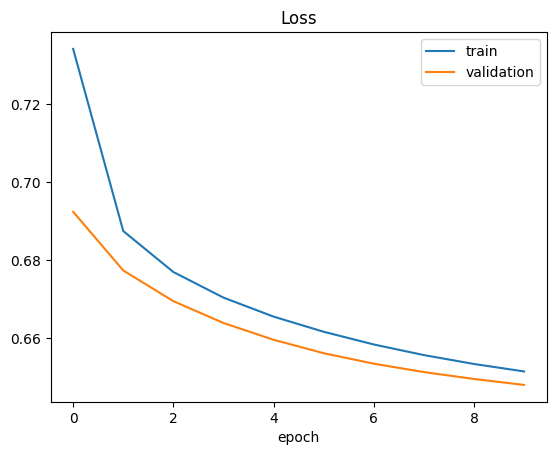

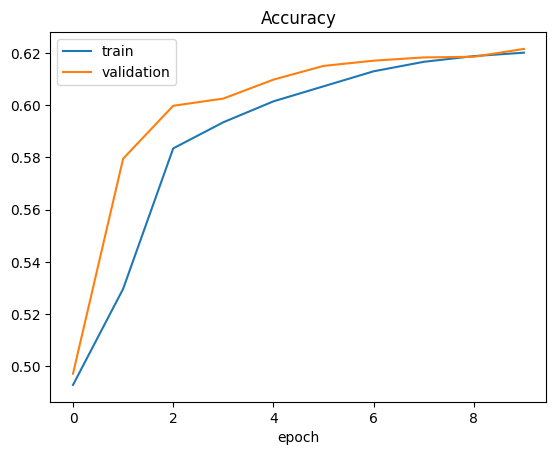

In [ ]:
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.title("Loss")
plt.xlabel("epoch")
plt.legend()
plt.show()

plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validation")
plt.title("Accuracy")
plt.xlabel("epoch")
plt.legend()
plt.show()

## Submission

In [ ]:
pred = (model.predict(X_test) > 0.5).astype(int).ravel()
submission = pd.DataFrame({"transaction_id": test["transaction_id"], "is_fraud": pred})
submission.to_csv("submission.csv", index=False)

938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  


In [ ]:
# Fill the Feedback Form